In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv(r"C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\Week 4\sales_data.csv")
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [51]:
# Checking missing values 
missing_values = df.isnull().sum().sum()
print(f"Found {missing_values} missing values.")

Found 0 missing values.


In [52]:
# Dropping rows with any missing values
df = df.dropna()

In [53]:
# Converting the 'Date' column to datetime objects for time-series analysis
df['Date'] = pd.to_datetime(df['Date'])

In [54]:
# Ensuring numerical columns are properly formatted
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Total_Sales'] = pd.to_numeric(df['Total_Sales'])
    
print("Data cleaning complete.")

Data cleaning complete.


In [55]:
# Generating basic statistical summaries
summary_stats = df.describe()
print("\nSummary Statistics for Numeric Columns:")
print(summary_stats[['Quantity', 'Price', 'Total_Sales']])


Summary Statistics for Numeric Columns:
         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000
std      2.588163  13917.630242  100161.085275


In [56]:
# Aggregate sales by Region
sales_by_region = df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)
print("\nTotal Sales by Region:")
print(sales_by_region)


Total Sales by Region:
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64


In [57]:
# Aggregate sales by Product
sales_by_product = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
print("\nTotal Sales by Product:")
print(sales_by_product)


Total Sales by Product:
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64


Text(0, 0.5, 'Total Sales (₹)')

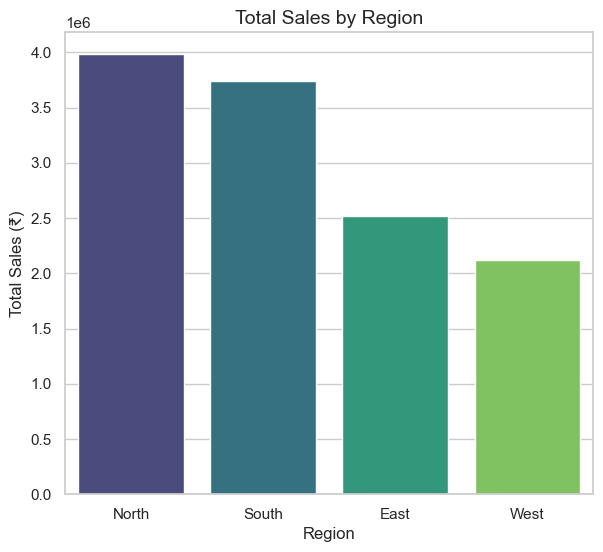

In [58]:
# Creating a figure for categorical comparisons
plt.figure(figsize=(15, 6))

# Bar Chart 1: Sales by Region
plt.subplot(1, 2, 1)
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='viridis', hue=sales_by_region.index)
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)

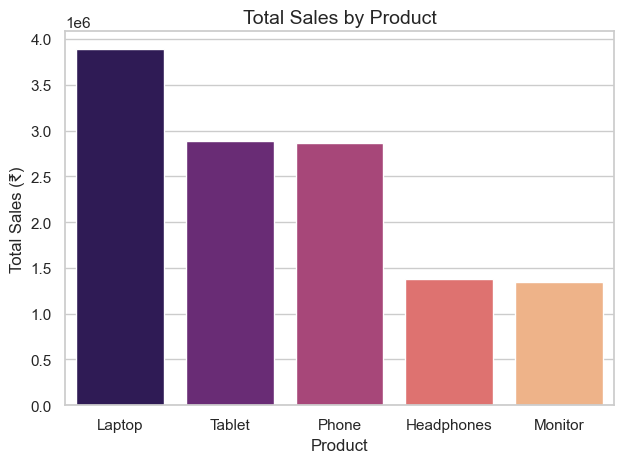

In [59]:
# Bar Chart 2: Sales by Product
plt.subplot(1, 1, 1)
sns.barplot(x=sales_by_product.index, y=sales_by_product.values, palette='magma', hue=sales_by_product.index)
plt.title('Total Sales by Product', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
plt.tight_layout()

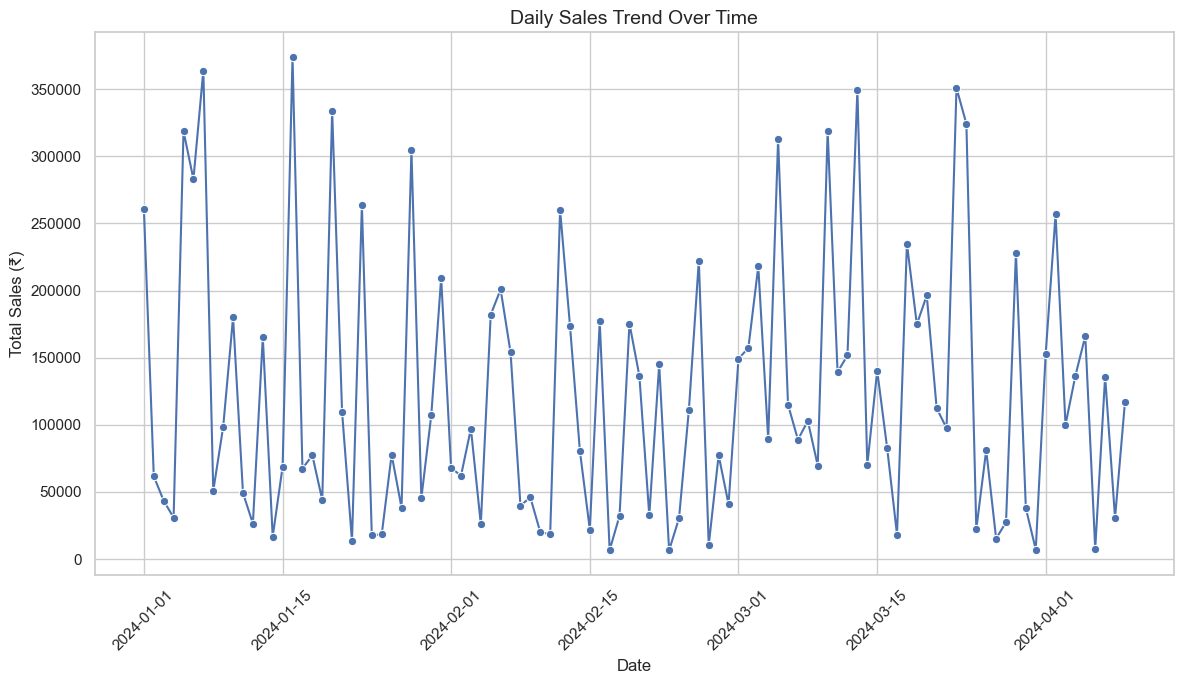

In [60]:
# Create a figure for the time-series trend
plt.figure(figsize=(12, 7))
    
# Group data by Date to see daily revenue trends
df_time = df.groupby('Date')['Total_Sales'].sum().reset_index()
# Line Chart: Daily Sales Trend
sns.lineplot(data=df_time, x='Date', y='Total_Sales', marker='o', color='b')
plt.title('Daily Sales Trend Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()